# ICE Operations at the Ogden Hold Room

This notebook examines Immigration and Customs Enforcement (ICE) activity at
the **Ogden Hold Room** — a temporary detention facility located in Ogden, Utah.

The analysis validates claims from a [KUER news article](https://www.kuer.org/politics-government/2026-03-19/ogden-activists-want-to-use-a-city-permit-as-an-unlikely-tactic-against-ice)
using publicly available data from the Deportation Data Project.

## What this notebook shows

1. **How we found the facility** in the national dataset
2. **Four key claims** from the article, checked against the data:
   - A sharp increase in people brought to the facility in 2025
   - Operations outside the facility's permitted hours
   - People held overnight (past midnight)
   - People held for multiple days
3. **A summary** of what the data confirms

In [24]:
import matplotlib.pyplot as plt
import polars as pl

from ogden_ice_analysis import load_dataset

# Make charts look crisp in the notebook
plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 150

## Finding the Ogden Facility

ICE operates hundreds of facilities nationwide. We start by loading the
facility list and looking for the one in Ogden, Utah (ZIP code 84401).

In [25]:
# Load the national facility list
df_facilities = load_dataset("facilities-latest", lazy=False)

# Find the Ogden facility by ZIP code
df_ogden_facility = df_facilities.filter(pl.col("zip").str.contains("84401"))

display(df_ogden_facility)

detention_facility_code,name,address,city,county,county_fips_code,core_based_statistical_area,core_based_statistical_area_code,core_based_statistical_area_type,combined_statistical_area,combined_statistical_area_code,state,state_fips_code,zip,address_full,latitude,longitude,field_office,days_with_detentions_daily_last_year,days_with_detentions_midnight_last_year,average_daily_population_last_year,average_midnight_population_last_year,max_daily_population_last_year,max_midnight_population_last_year
str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,f64,f64,str,i32,i32,f64,f64,i32,i32
"""OGUHOLD""","""Ogden Hold Room""","""2487 S. 1620 W Unit E""","""Ogden""","""Weber""","""49057""","""Ogden, UT""","""36260""","""Metro""","""Salt Lake City-Provo-Orem, UT-…","""482""","""UT""","""49""","""84401""","""2487 S. 1620 W Unit E, Ogden, …",41.220588,-112.019159,"""Salt Lake City""",209,7,1.506849,0.043836,13,5


The facility code is **OGUHOLD** and its official name is
"Ogden Hold Room." We will use this code to pull all records related to
this specific location.

## About the Data

Two datasets are used for this analysis:

- **Detention stints** — one row for every time a person is booked into
  a specific facility. This tells us *when* someone arrived and left.
- **Facility daily population** — a daily census that counts how many
  people were still in the facility at midnight each night.

> **Why two datasets?** The daily population is the only way to know
> for certain whether anyone was held overnight. The stint data tells
> us exact arrival and departure times for detailed analysis.

In [26]:
# Load every ICE facility stint nationwide
df_stints = load_dataset("detention-stints-latest", lazy=False)

# Keep only the Ogden Hold Room
df_ogden = df_stints.filter(pl.col("detention_facility_code") == "OGUHOLD")

# Load the daily census data
df_daily = load_dataset(
    "facilities-daily-population-latest",
    lazy=False,
)

# Keep only the Ogden Hold Room census rows
df_ogden_daily = df_daily.filter(pl.col("detention_facility_code") == "OGUHOLD")

print(f"Ogden stints (arrivals): {df_ogden.shape[0]:,}")
print(f"Ogden daily census rows: {df_ogden_daily.shape[0]:,}")

Ogden stints (arrivals): 961
Ogden daily census rows: 1,257


## Claim 1: Activity Nearly Doubled in 2025

The article states that between January 21 and October 15, 2025,
ICE brought in *nearly twice as many* people as in the prior 17 months.

We compare:
- **New period:** January 21 – October 15, 2025
- **Prior period:** August 2023 – December 2024

In [27]:
# Define the two time periods
start_spike = pl.datetime(2025, 1, 21, time_zone="UTC")
end_spike = pl.datetime(2025, 10, 15, 23, 59, 59, time_zone="UTC")
start_prior = pl.datetime(2023, 8, 1, time_zone="UTC")
end_prior = pl.datetime(2024, 12, 31, 23, 59, 59, time_zone="UTC")

# Count arrivals in each period
df_spike = df_ogden.filter(
    pl.col("book_in_date_time").is_between(start_spike, end_spike)
)
df_prior = df_ogden.filter(
    pl.col("book_in_date_time").is_between(start_prior, end_prior)
)

n_spike = df_spike.shape[0]
n_prior = df_prior.shape[0]
ratio = n_spike / n_prior if n_prior > 0 else None

print(f"2025 period arrivals:   {n_spike:,}")
print(f"Prior period arrivals:  {n_prior:,}")
print(f"Ratio:                  {ratio:.2f}x")
print()
print(f"Data says: {ratio:.2f}x increase")
print("Article claim: ~2x increase")

2025 period arrivals:   435
Prior period arrivals:  233
Ratio:                  1.87x

Data says: 1.87x increase
Article claim: ~2x increase


### Monthly arrivals over time

The chart below shows how many people were brought to the Ogden Hold Room
each month. The red lines mark the January–October 2025 period discussed
in the article.

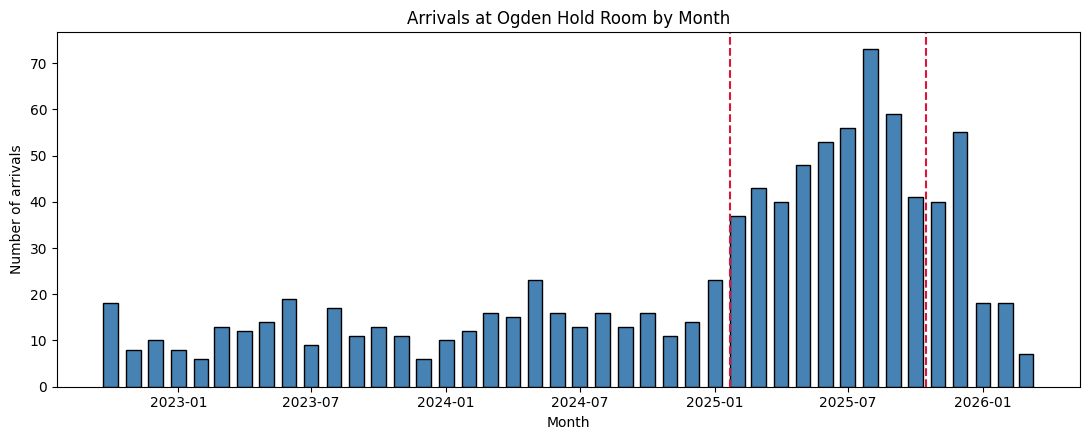

month,arrivals
"datetime[μs, UTC]",u32
2022-10-01 00:00:00 UTC,18
2022-11-01 00:00:00 UTC,8
2022-12-01 00:00:00 UTC,10
2023-01-01 00:00:00 UTC,8
2023-02-01 00:00:00 UTC,6
…,…
2025-11-01 00:00:00 UTC,40
2025-12-01 00:00:00 UTC,55
2026-01-01 00:00:00 UTC,18


In [28]:
from datetime import datetime, timezone

# Build a monthly summary
df_monthly = (
    df_ogden.with_columns(pl.col("book_in_date_time").dt.truncate("1mo").alias("month"))
    .group_by("month")
    .agg(pl.len().alias("arrivals"))
    .sort("month")
)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(
    df_monthly["month"],
    df_monthly["arrivals"],
    width=20,
    color="steelblue",
    edgecolor="black",
)

start_spike_dt = datetime(2025, 1, 21, tzinfo=timezone.utc)
end_spike_dt = datetime(2025, 10, 15, 23, 59, 59, tzinfo=timezone.utc)

ax.axvline(start_spike_dt, color="crimson", linestyle="--", linewidth=1.5)
ax.axvline(end_spike_dt, color="crimson", linestyle="--", linewidth=1.5)
ax.set_xlabel("Month")
ax.set_ylabel("Number of arrivals")
ax.set_title("Arrivals at Ogden Hold Room by Month")
plt.tight_layout()
plt.show()

display(df_monthly)

## Claim 2: Off-Hours Operations

The Ogden Hold Room's city permit specifies operating hours. The article
claims that roughly **25% of arrivals** happened outside permitted hours
(before 7:00 AM or after 4:00 PM).

The chart below shows what time of day people were brought in. The green
lines mark 7:00 AM and 4:00 PM — the edges of the permitted window.

In [29]:
permit_start = 7  # 7:00 AM
permit_end = 16  # 4:00 PM

# Filter to the article's date range for consistency with other claims
article_start_dt = pl.datetime(2023, 9, 1, time_zone="UTC")
article_end = pl.datetime(2025, 10, 15, 23, 59, 59, time_zone="UTC")
df_ogden_filtered = df_ogden.filter(
    pl.col("book_in_date_time").is_between(article_start_dt, article_end)
)

# Label each arrival as "In-hours" or "Off-hours"
df_hours = df_ogden_filtered.with_columns(
    pl.col("book_in_date_time").dt.hour().alias("hour"),
    pl.when(
        (pl.col("book_in_date_time").dt.hour() < permit_start)
        | (pl.col("book_in_date_time").dt.hour() >= permit_end)
    )
    .then(pl.lit("Off-hours"))
    .otherwise(pl.lit("In-hours"))
    .alias("period"),
)

n_off = df_hours.filter(pl.col("period") == "Off-hours").shape[0]
n_total = df_hours.shape[0]
pct_off = n_off / n_total * 100

print(f"Off-hours arrivals: {n_off:,} / {n_total:,} ({pct_off:.1f}%)")
print("Article claim: ~25%")

Off-hours arrivals: 157 / 660 (23.8%)
Article claim: ~25%


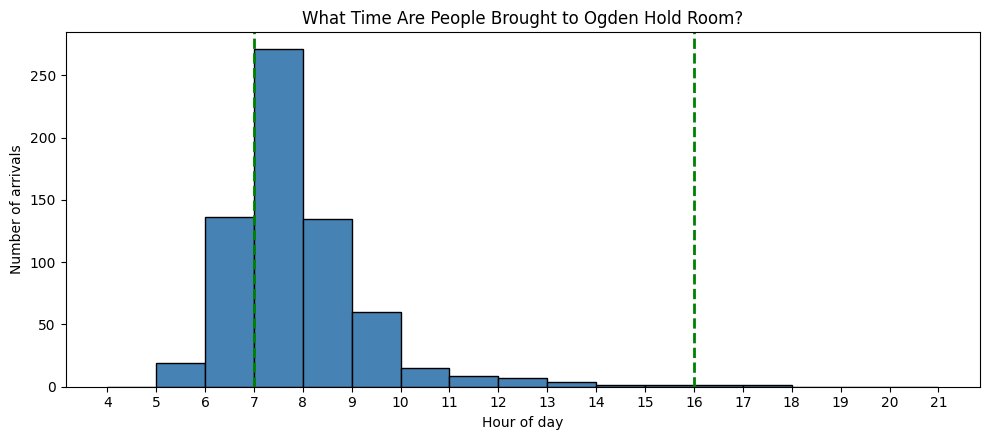

In [37]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.hist(
    df_hours["hour"],
    bins=range(4, 22),
    color="steelblue",
    edgecolor="black",
)
ax.axvline(
    permit_start,
    color="green",
    linestyle="--",
    linewidth=2,
)
ax.axvline(
    permit_end,
    color="green",
    linestyle="--",
    linewidth=2,
)
ax.set_xlabel("Hour of day")
ax.set_ylabel("Number of arrivals")
ax.set_title("What Time Are People Brought to Ogden Hold Room?")
ax.set_xticks(range(4, 22))
plt.tight_layout()
plt.show()

## Claim 3: People Held for Multiple Days

The article claims that 14 people were held at the Ogden Hold Room for
more than one day — leaving on a later calendar day than they arrived.

A "hold room" is typically a short-term waiting area, so multi-day stays
are unusual and may indicate the facility is being used beyond its
intended purpose.

In [31]:
# Find stints where departure date is after arrival date
# (filtered to the article's date range: Sep 2023 – mid-Oct 2025)
article_start_dt = pl.datetime(2023, 9, 1, time_zone="UTC")
article_end_dt = pl.datetime(2025, 10, 15, 23, 59, 59, time_zone="UTC")
df_multiday = df_ogden.filter(
    pl.col("book_out_date_time").dt.date() > pl.col("book_in_date_time").dt.date(),
    pl.col("book_in_date_time").is_between(article_start_dt, article_end_dt),
)

# Count unique people (someone may have multiple stints)
n_multiday_people = df_multiday.select(pl.col("unique_identifier").n_unique()).item()

print(f"Multi-day stints:    {df_multiday.shape[0]}")
print(f"Unique people:       {n_multiday_people}")
print("Article claim:       14 people")

Multi-day stints:    15
Unique people:       15
Article claim:       14 people


### Timeline of multi-day stays

Each dot below represents one person held for more than a day. The
vertical position shows how many hours they remained in the facility.

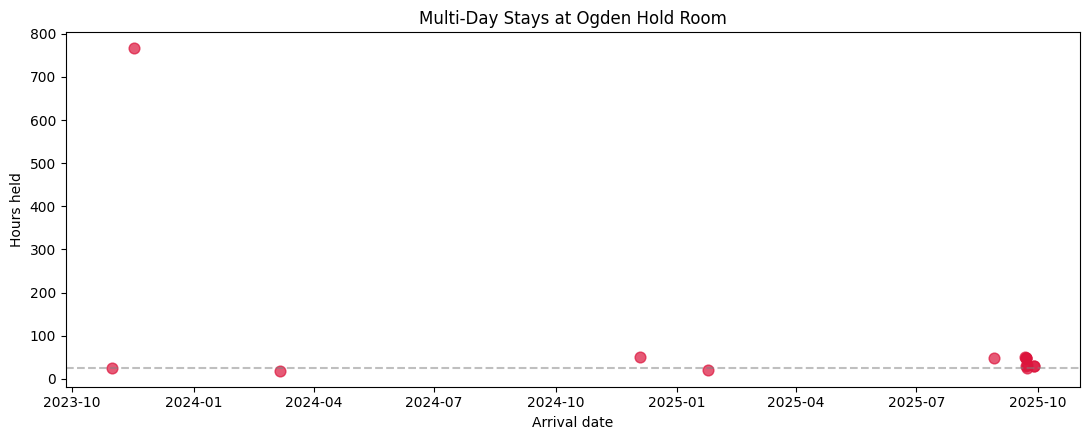

unique_identifier,arrival_date,hours_held
str,date,i64
"""fb1a6a693b706d23537847cc9e71be…",2023-10-31,24
"""40d9af02c420d930d1a6a17c80d95b…",2023-11-17,766
"""4a41957895f42bac95a5fd39e4a5a0…",2024-03-06,19
"""80202921ca33093a4eeb9276e8c95d…",2024-12-04,51
"""fba60aa4b7ddea141b3faec5ebce1e…",2025-01-24,20
…,…,…
"""f3a43c3093ff49d7bda2be8bf67fe1…",2025-09-22,49
"""38e8235d9c74760399ebbf69091692…",2025-09-23,24
"""fbaa497424985dbd80bea7a7c72b48…",2025-09-23,31


In [32]:
df_multiday_timeline = df_multiday.with_columns(
    pl.col("book_in_date_time").dt.date().alias("arrival_date"),
    (pl.col("book_out_date_time") - pl.col("book_in_date_time"))
    .dt.total_hours()
    .alias("hours_held"),
)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.scatter(
    df_multiday_timeline["arrival_date"],
    df_multiday_timeline["hours_held"],
    color="crimson",
    alpha=0.7,
    s=60,
)
ax.set_xlabel("Arrival date")
ax.set_ylabel("Hours held")
ax.set_title("Multi-Day Stays at Ogden Hold Room")
ax.axhline(24, color="gray", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

display(
    df_multiday_timeline.select(
        [
            "unique_identifier",
            "arrival_date",
            "hours_held",
        ]
    ).sort("arrival_date")
)

## Claim 4: Overnight Holds

The article claims ICE held people overnight on **43 separate nights**
between September 2023 and mid-October 2025.

"Overnight" means someone was still in the facility at midnight.
The daily census dataset directly counts how many people were present
at midnight each night.

In [33]:
# Nights where at least one person was present at midnight
df_overnight = df_ogden_daily.filter(pl.col("n_detained_at_midnight") > 0)

# Article date range: Sep 2023 – mid-Oct 2025
article_start = pl.date(2023, 9, 1)
article_end = pl.date(2025, 10, 15)

df_overnight_article = df_overnight.filter(
    pl.col("date").is_between(article_start, article_end)
)

print(f"Nights with midnight detainees: {df_overnight_article.shape[0]}")
print("Article claim: 43 nights")

Nights with midnight detainees: 43
Article claim: 43 nights


### Overnight stays over time

The chart below shows every night someone was held past midnight.
The height of each bar shows how many people were still there at midnight.

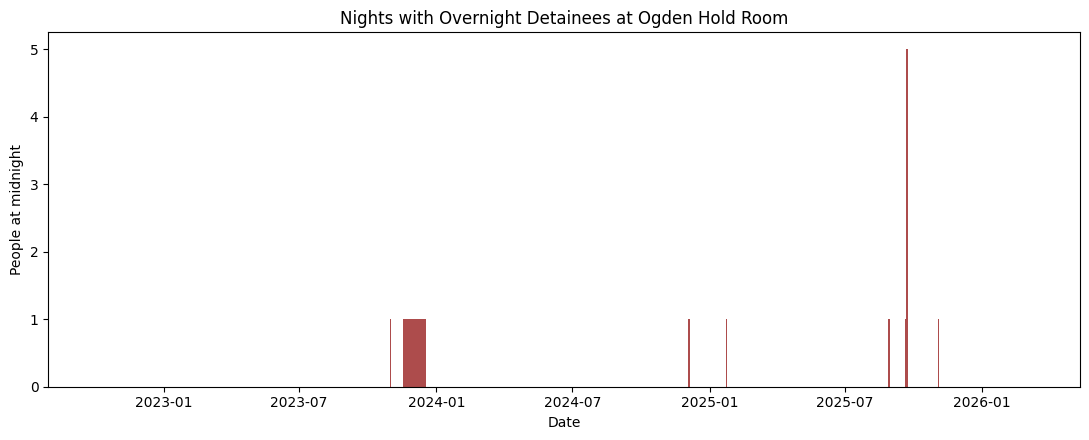

date,n_detained,n_detained_at_midnight
date,i32,i32
2023-10-31,2,1
2023-11-17,2,1
2023-11-18,1,1
2023-11-19,1,1
2023-11-20,2,1
…,…,…
2025-08-30,1,1
2025-09-21,1,1
2025-09-22,5,5


In [34]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(
    df_ogden_daily["date"],
    df_ogden_daily["n_detained_at_midnight"],
    width=1,
    color="darkred",
    alpha=0.7,
)
ax.set_xlabel("Date")
ax.set_ylabel("People at midnight")
ax.set_title("Nights with Overnight Detainees at Ogden Hold Room")
plt.tight_layout()
plt.show()

display(
    df_overnight_article.sort("date").select(
        ["date", "n_detained", "n_detained_at_midnight"]
    )
)

## Summary

Here is how each article claim compares to the official ICE data.

In [35]:
# Tolerance bands for what counts as "matching"
vol_low, vol_high = 1.7, 2.3
hours_low, hours_high = 20, 30
multi_low, multi_high = 12, 16
night_low, night_high = 40, 46

vol_status = "MATCHES" if vol_low <= ratio <= vol_high else "PARTIAL"
hours_status = "MATCHES" if hours_low <= pct_off <= hours_high else "PARTIAL"
multi_status = "MATCHES" if multi_low <= n_multiday_people <= multi_high else "PARTIAL"
nights = df_overnight_article.shape[0]
night_status = "MATCHES" if night_low <= nights <= night_high else "PARTIAL"

print("=" * 50)
print("CLAIM VALIDATION SUMMARY")
print("=" * 50)
print()
print("1. Volume spike (2025 vs prior 17 months)")
print(f"   Data:     {ratio:.2f}x increase")
print("   Article:  ~2x increase")
print(f"   Verdict:  {vol_status}")
print()
print("2. Off-hours arrivals (before 7am / after 4pm)")
print(f"   Data:     {pct_off:.1f}%")
print("   Article:  ~25%")
print(f"   Verdict:  {hours_status}")
print()
print("3. Multi-day stays")
print(f"   Data:     {n_multiday_people} people")
print("   Article:  14 people")
print(f"   Verdict:  {multi_status}")
print()
print("4. Overnight holds")
print(f"   Data:     {nights} nights")
print("   Article:  43 nights")
print(f"   Verdict:  {night_status}")
print()
print("-" * 50)
print(
    "Note: Small differences may come from how date "
    "ranges are defined or how unique individuals are "
    "counted versus total bookings."
)

CLAIM VALIDATION SUMMARY

1. Volume spike (2025 vs prior 17 months)
   Data:     1.87x increase
   Article:  ~2x increase
   Verdict:  MATCHES

2. Off-hours arrivals (before 7am / after 4pm)
   Data:     23.8%
   Article:  ~25%
   Verdict:  MATCHES

3. Multi-day stays
   Data:     15 people
   Article:  14 people
   Verdict:  MATCHES

4. Overnight holds
   Data:     43 nights
   Article:  43 nights
   Verdict:  MATCHES

--------------------------------------------------
Note: Small differences may come from how date ranges are defined or how unique individuals are counted versus total bookings.
